## **Modelagem:**

In [13]:
# Bibliotecas
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Carregar dados processados
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_target.csv').squeeze()

print(f"\nDados carregados:")
print(f"Features: {X.shape}")
print(f"Target: {y.shape}")
print(f"Taxa de churn: {y.mean()*100:.2f}%")


Dados carregados:
Features: (10000, 29)
Target: (10000,)
Taxa de churn: 22.26%


## **Divisão de treino e teste:**

In [14]:
#Split estratificado para manter proporção de churn
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape} - {y_train.mean()*100:.2f}% churn")
print(f"Teste: {X_test.shape} - {y_test.mean()*100:.2f}% churn")

Treino: (8000, 29) - 22.26% churn
Teste: (2000, 29) - 22.25% churn


## **Avaliação do Modelo:**

In [23]:
# Função de avaliação CORRIGIDA para XGBoost
def avaliar_modelo(modelo, X_train, y_train, X_test, y_test, nome_modelo):
    
    # Converter para numpy se for XGBoost (para evitar erro de dtype)
    if 'XGB' in nome_modelo or 'xgb' in str(type(modelo)).lower():
        X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
        y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
        X_test_np = X_test.values if hasattr(X_test, 'values') else X_test
        y_test_np = y_test.values if hasattr(y_test, 'values') else y_test
        
        modelo.fit(X_train_np, y_train_np)
        y_pred = modelo.predict(X_test_np)
        y_proba = modelo.predict_proba(X_test_np)[:, 1]
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]
    
    # Calcular métricas
    metricas = {
        'Modelo': nome_modelo,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    }
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    # Plotar resultados
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Matriz de confusão
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Matriz de Confusão - {nome_modelo}')
    axes[0].set_xlabel('Predito')
    axes[0].set_ylabel('Real')
    
    # Curva ROC
    axes[1].plot(fpr, tpr, label=f'AUC = {metricas["AUC-ROC"]:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1].set_xlabel('Taxa de Falso Positivo')
    axes[1].set_ylabel('Taxa de Verdadeiro Positivo')
    axes[1].set_title(f'Curva ROC - {nome_modelo}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Feature importance (para modelos que suportam)
    try:
        if hasattr(modelo, 'feature_importances_'):
            importancias = pd.DataFrame({
                'feature': X_train.columns if hasattr(X_train, 'columns') else [f'f{i}' for i in range(X_train.shape[1])],
                'importancia': modelo.feature_importances_
            }).sort_values('importancia', ascending=False).head(10)
            
            sns.barplot(data=importancias, y='feature', x='importancia', ax=axes[2], palette='viridis')
            axes[2].set_title(f'Top 10 Features - {nome_modelo}')
        elif hasattr(modelo, 'coef_'):
            importancias = pd.DataFrame({
                'feature': X_train.columns if hasattr(X_train, 'columns') else [f'f{i}' for i in range(X_train.shape[1])],
                'importancia': np.abs(modelo.coef_[0])
            }).sort_values('importancia', ascending=False).head(10)
            
            sns.barplot(data=importancias, y='feature', x='importancia', ax=axes[2], palette='viridis')
            axes[2].set_title(f'Top 10 Coeficientes - {nome_modelo}')
        else:
            axes[2].text(0.5, 0.5, 'Modelo não suporta\nimportância de features', 
                        ha='center', va='center', fontsize=12)
            axes[2].set_title('Importância de Features')
    except:
        axes[2].text(0.5, 0.5, 'Erro ao calcular\nimportância', 
                    ha='center', va='center', fontsize=12)
        axes[2].set_title('Importância de Features')
    
    plt.tight_layout()
    plt.savefig(f'../reports/figures/{nome_modelo.replace(" ", "_")}_resultados.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return metricas

## **Treinar Múltiplos Modelos:**


Treinando Regressão Logística...


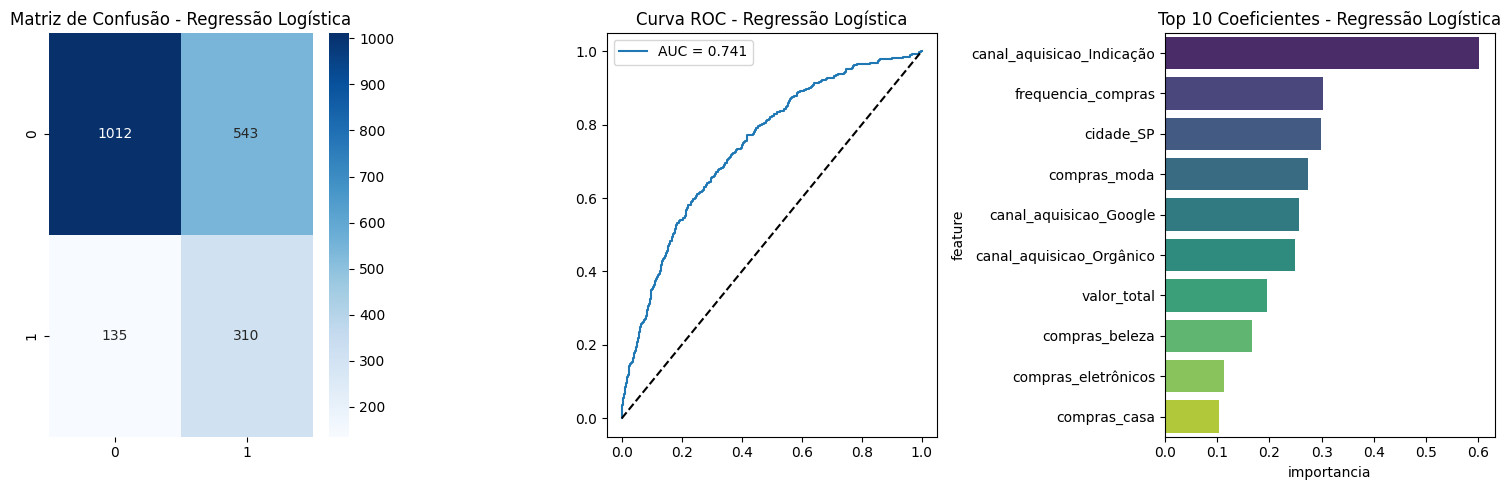

CV AUC-ROC: 0.716 (+/- 0.004)

Treinando Árvore de Decisão...


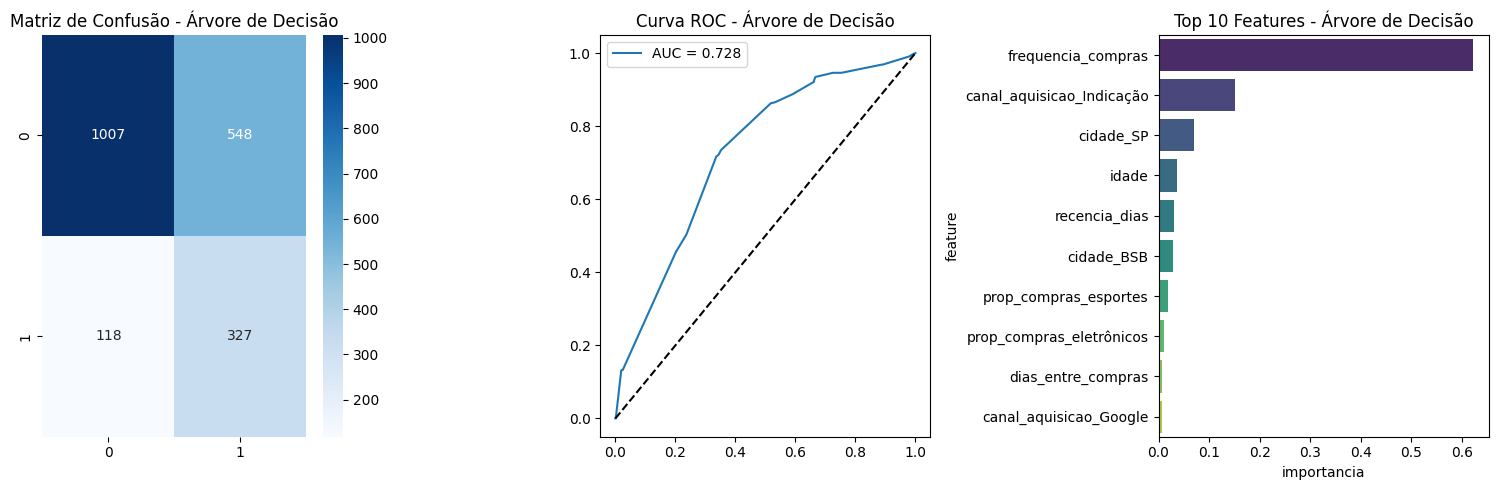

CV AUC-ROC: 0.705 (+/- 0.013)

Treinando Random Forest...


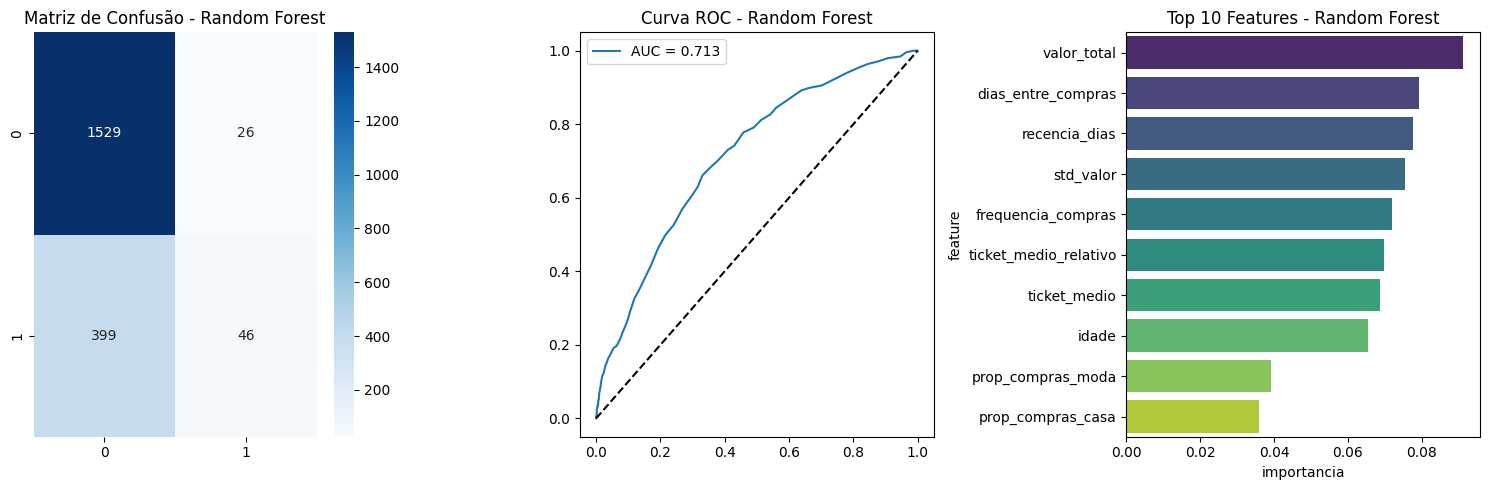

CV AUC-ROC: 0.690 (+/- 0.011)

Treinando XGBoost...


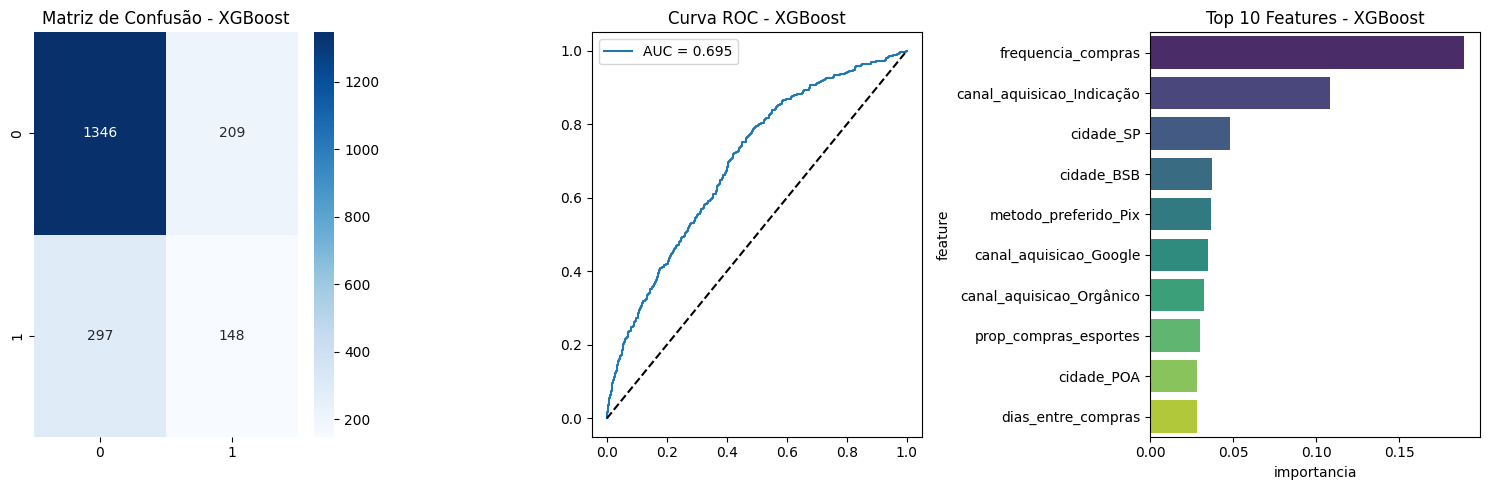

CV AUC-ROC: 0.669 (+/- 0.019)


In [16]:
# Lista de modelos para testar
modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', scale_pos_weight=2)
}

# Dicionário para armazenar resultados
resultados = []
for nome, modelo in modelos.items():
    print(f"\nTreinando {nome}...")
    metricas = avaliar_modelo(modelo, X_train, y_train, X_test, y_test, nome)
    resultados.append(metricas)
    
    # Cross-validation
    cv_scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='roc_auc')
    print(f"CV AUC-ROC: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

## **Comparação de Modelos:**


RESULTADOS FINAIS:
                     Acurácia  Precisão  Recall  F1-Score  AUC-ROC
Modelo                                                            
Regressão Logística     0.661     0.363   0.697     0.478    0.741
Árvore de Decisão       0.667     0.374   0.735     0.495    0.728
Random Forest           0.788     0.639   0.103     0.178    0.713
XGBoost                 0.747     0.415   0.333     0.369    0.695


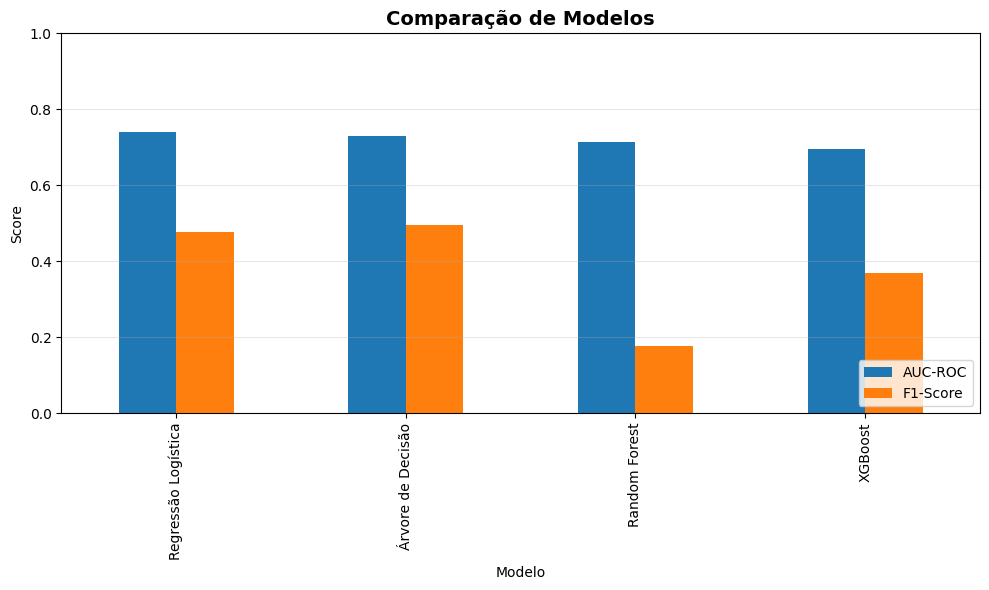

In [17]:
# Criar DataFrame de resultados
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print("\nRESULTADOS FINAIS:")
print(df_resultados.round(3).to_string())

# Plot comparativo
fig, ax = plt.subplots(figsize=(10, 6))
df_resultados[['AUC-ROC', 'F1-Score']].plot(kind='bar', ax=ax)
ax.set_title('Comparação de Modelos', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## **Tuning dos Modelos:**

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Melhores parâmetros: {'C': 0.1, 'l1_ratio': 0.1, 'penalty': 'l1', 'solver': 'saga'}
Melhor AUC-ROC (CV): 0.7161
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Melhores parâmetros: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 50, 'n_estimators': 300}
Melhor AUC-ROC (CV): 0.7116
Fitting 3 folds for each of 972 candidates, totalling 2916 fits

Melhores parâmetros: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.7}
Melhor AUC-ROC (CV): 0.7194

📈 Avaliando Logistic (Otimizado)...


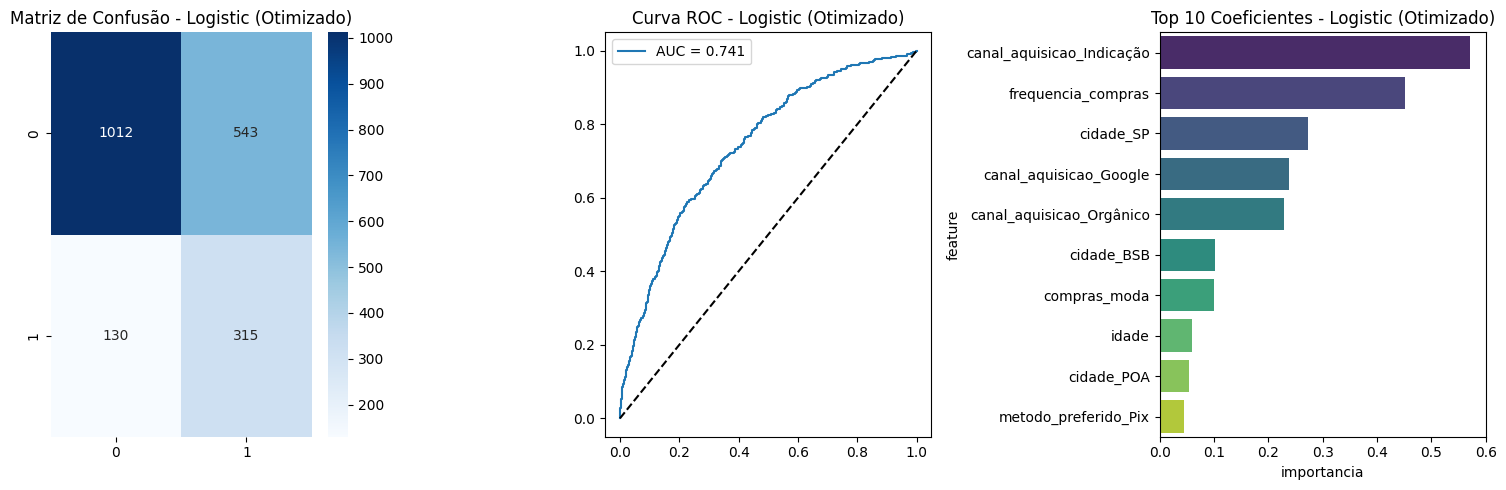


📈 Avaliando Random Forest (Otimizado)...


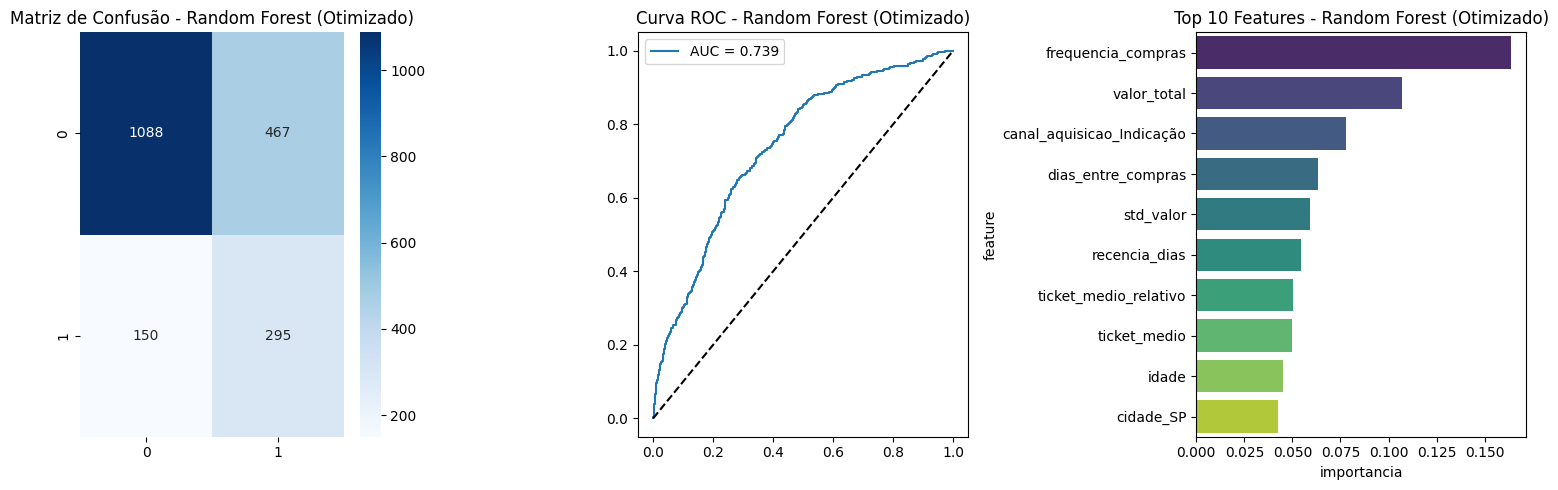


📈 Avaliando XGBoost (Otimizado)...


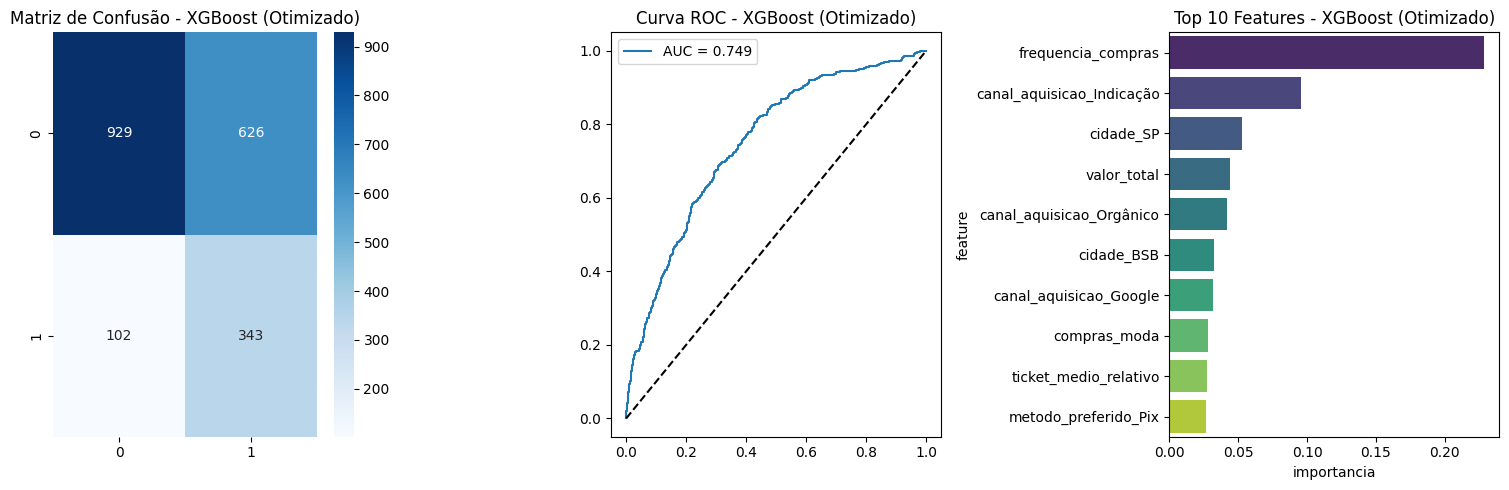


RESULTADOS DOS MODELOS OTIMIZADOS:
                           Acurácia  Precisão  Recall  F1-Score  AUC-ROC
Modelo                                                                  
Logistic (Otimizado)          0.664     0.367   0.708     0.483    0.741
Random Forest (Otimizado)     0.692     0.387   0.663     0.489    0.739
XGBoost (Otimizado)           0.636     0.354   0.771     0.485    0.749


In [18]:
# Tuning Regressão Logística
# Bibliotecas
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectFromModel

# Grid Search para Regressão Logística
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['saga'],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9]  # para elasticnet
}

lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)

grid_lr = GridSearchCV(
    lr, 
    param_grid_lr, 
    cv=StratifiedKFold(5), 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print(f"\nMelhores parâmetros: {grid_lr.best_params_}")
print(f"Melhor AUC-ROC (CV): {grid_lr.best_score_:.4f}")

lr_otimizado = grid_lr.best_estimator_

# Tuning Random Forest
# Biblioteca
from sklearn.ensemble import RandomForestClassifier

# Grid Search para Random Forest
param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=StratifiedKFold(3),  # 3-fold por ser mais pesado
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print(f"\nMelhores parâmetros: {grid_rf.best_params_}")
print(f"Melhor AUC-ROC (CV): {grid_rf.best_score_:.4f}")

rf_otimizado = grid_rf.best_estimator_

# Tuning XGBoost
# Biblioteca
from xgboost import XGBClassifier

# Calcular scale_pos_weight
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Grid Search para XGBoost
param_grid_xgb = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=StratifiedKFold(3),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print(f"\nMelhores parâmetros: {grid_xgb.best_params_}")
print(f"Melhor AUC-ROC (CV): {grid_xgb.best_score_:.4f}")

xgb_otimizado = grid_xgb.best_estimator_

# Comparação dos modelos otimizados
modelos_otimizados = {
    'Logistic (Otimizado)': lr_otimizado,
    'Random Forest (Otimizado)': rf_otimizado,
    'XGBoost (Otimizado)': xgb_otimizado
}

resultados_otimizados = []

for nome, modelo in modelos_otimizados.items():
    print(f"\nAvaliando {nome}...")
    metricas = avaliar_modelo(modelo, X_train, y_train, X_test, y_test, nome)
    resultados_otimizados.append(metricas)

df_otimizados = pd.DataFrame(resultados_otimizados).set_index('Modelo')
print("\nRESULTADOS DOS MODELOS OTIMIZADOS:")
print(df_otimizados.round(3).to_string())

## **Feature Engineering Avançada:**

In [19]:
# Interações entre features importantes
# Biblioteca
from sklearn.preprocessing import PolynomialFeatures

# Selecionar top features do melhor modelo
melhor_modelo = xgb_otimizado  
importancias = pd.DataFrame({
    'feature': X.columns,
    'importancia': melhor_modelo.feature_importances_
}).sort_values('importancia', ascending=False)

top_features = importancias.head(10)['feature'].tolist()
print(f"Top 10 features para criar interações: {top_features}")

# Criar interações apenas com as top features
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_top = X[top_features]
X_interacoes = poly.fit_transform(X_top)

# Nomes das novas features
nomes_interacoes = poly.get_feature_names_out(top_features)
X_interacoes_df = pd.DataFrame(
    X_interacoes, 
    columns=nomes_interacoes,
    index=X.index
)

# Adicionar ao dataset original
X_avancado = pd.concat([X, X_interacoes_df], axis=1)
print(f"Features originais: {X.shape[1]}")
print(f"Features com interações: {X_avancado.shape[1]}")


Top 10 features para criar interações: ['frequencia_compras', 'canal_aquisicao_Indicação', 'cidade_SP', 'valor_total', 'canal_aquisicao_Orgânico', 'cidade_BSB', 'canal_aquisicao_Google', 'compras_moda', 'ticket_medio_relativo', 'metodo_preferido_Pix']
Features originais: 29
Features com interações: 84


## **Treino com Features Avançadas:**

Dados escalados com sucesso!
   Treino: (8000, 84)
   Teste: (2000, 84)


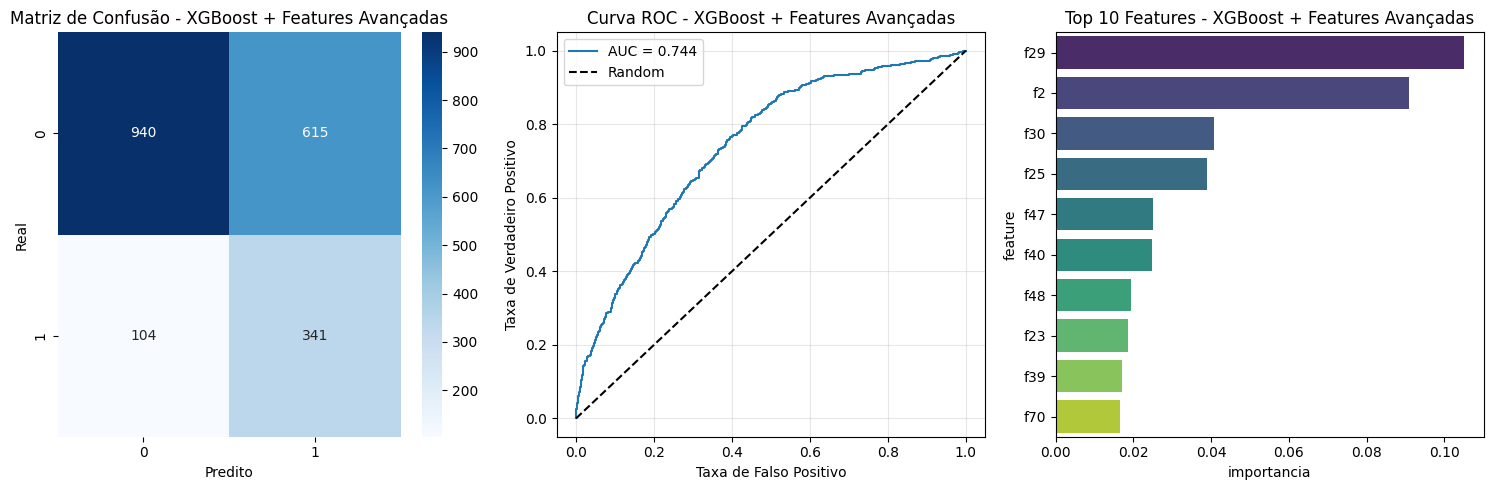

In [24]:
# Bibliotecas
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Split novamente
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_avancado, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar
scaler_adv = StandardScaler()
X_train_adv_scaled = pd.DataFrame(
    scaler_adv.fit_transform(X_train_adv),
    columns=X_train_adv.columns
)
X_test_adv_scaled = pd.DataFrame(
    scaler_adv.transform(X_test_adv),
    columns=X_test_adv.columns
)

print(f"Dados escalados com sucesso!")
print(f"   Treino: {X_train_adv_scaled.shape}")
print(f"   Teste: {X_test_adv_scaled.shape}")

# Conversão para Numpy (para evitar erro do XGBoost)
X_train_adv_np = X_train_adv_scaled.values
y_train_adv_np = y_train_adv.values
X_test_adv_np = X_test_adv_scaled.values
y_test_adv_np = y_test_adv.values

# Treinar XGBoost com features avançadas
xgb_avancado = XGBClassifier(
    **grid_xgb.best_params_,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

# Usar a função de avaliação 
metricas_avancado = avaliar_modelo(
    xgb_avancado, 
    X_train_adv_np, y_train_adv_np, 
    X_test_adv_np, y_test_adv_np, 
    "XGBoost + Features Avançadas"
)

## **Stacking:**

Treinando Stacking Ensemble...


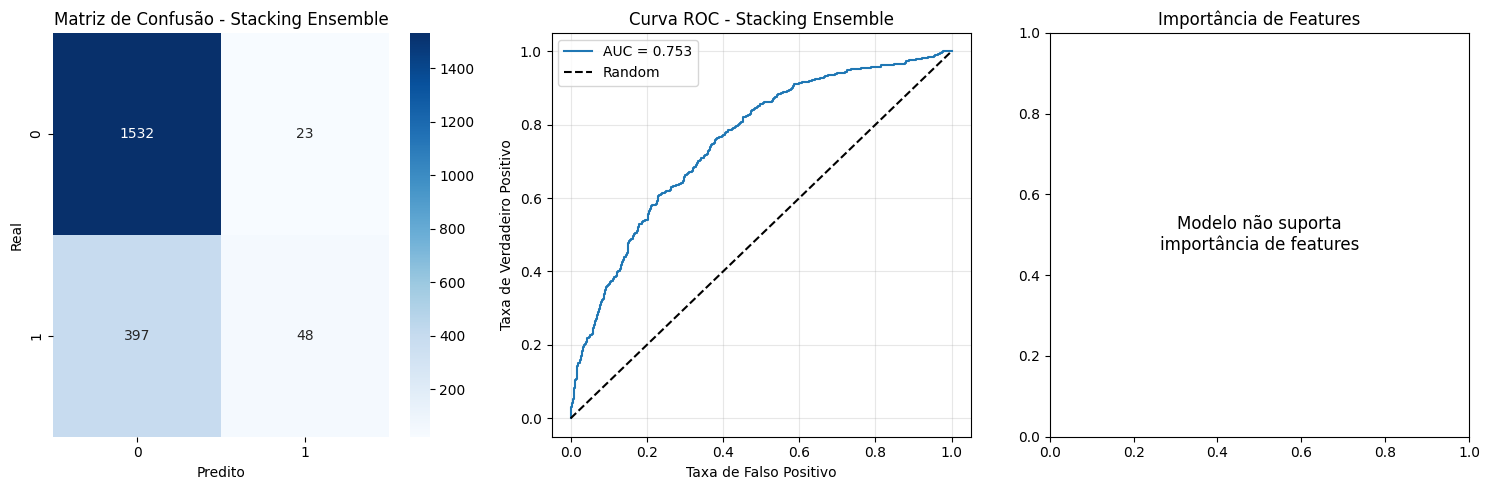

In [25]:
# Bibliotecas
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Modelos base (com melhores parâmetros)
base_models = [
    ('lr', lr_otimizado),
    ('rf', rf_otimizado),
    ('xgb', xgb_otimizado)
]

# Meta-modelo 
meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba'
)

print("Treinando Stacking Ensemble...")
metricas_stacking = avaliar_modelo(
    stacking, 
    X_train, y_train, 
    X_test, y_test, 
    "Stacking Ensemble"
)

## **Análise de Threshold Otimizado:**

In [26]:
# Bibliotecas
from sklearn.metrics import precision_recall_curve

# Usar o melhor modelo (Stacking ou XGBoost Avançado)
modelo_final = stacking  # ou xgb_avancado
y_proba = modelo_final.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Calcular F1 para cada threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
idx_otimo = np.argmax(f1_scores[:-1])
threshold_otimo = thresholds[idx_otimo]

print(f"\nThreshold ótimo encontrado: {threshold_otimo:.3f}")
print(f"   Precision: {precision[idx_otimo]:.3f}")
print(f"   Recall: {recall[idx_otimo]:.3f}")
print(f"   F1-Score: {f1_scores[idx_otimo]:.3f}")

# Aplicar threshold otimizado
y_pred_otimo = (y_proba >= threshold_otimo).astype(int)

print(f"\nComparação com threshold padrão (0.5):")
print(f"   Recall padrão: {recall_score(y_test, (y_proba >= 0.5).astype(int)):.3f}")
print(f"   Recall otimizado: {recall_score(y_test, y_pred_otimo):.3f}")


Threshold ótimo encontrado: 0.296
   Precision: 0.429
   Recall: 0.609
   F1-Score: 0.504

Comparação com threshold padrão (0.5):
   Recall padrão: 0.108
   Recall otimizado: 0.609


## **Resultados Finais:**

In [30]:
# Definir pesos para cada métrica (priorizando RECALL para churn)
pesos = {
    'Recall': 0.5,      # Mais importante - encontrar quem vai cancelar
    'AUC-ROC': 0.3,     # Poder preditivo geral
    'F1-Score': 0.1,    # Equilíbrio
    'Precisão': 0.1     # Evitar muitos falsos alertas
}

print(f"\nCritérios de seleção (priorizando RECALL):")
print(f"   Recall: {pesos['Recall']*100}%")
print(f"   AUC-ROC: {pesos['AUC-ROC']*100}%")
print(f"   F1-Score: {pesos['F1-Score']*100}%")
print(f"   Precisão: {pesos['Precisão']*100}%")

# Normalizar as métricas (0-1)
from sklearn.preprocessing import MinMaxScaler

# Selecionar apenas as colunas numéricas
metricas_numericas = todos_resultados[['Recall', 'AUC-ROC', 'F1-Score', 'Precisão']].copy()

# Normalizar
scaler = MinMaxScaler()
metricas_normalizadas = pd.DataFrame(
    scaler.fit_transform(metricas_numericas),
    columns=metricas_numericas.columns,
    index=metricas_numericas.index
)

# Calcular score ponderado
metricas_normalizadas['score_negocio'] = (
    metricas_normalizadas['Recall'] * pesos['Recall'] +
    metricas_normalizadas['AUC-ROC'] * pesos['AUC-ROC'] +
    metricas_normalizadas['F1-Score'] * pesos['F1-Score'] +
    metricas_normalizadas['Precisão'] * pesos['Precisão']
)

# Ordenar por score
melhores_modelos = metricas_normalizadas.sort_values('score_negocio', ascending=False)

print("\nRANKING DE MODELOS (VALORES NORMALIZADOS - comparação relativa):")
print(melhores_modelos[['Recall', 'AUC-ROC', 'F1-Score', 'Precisão', 'score_negocio']].round(3).to_string())

print("\nVALORES REAIS DAS MÉTRICAS (TOP 5):")
top5 = melhores_modelos.head(5).index
for modelo in top5:
    recall_real = todos_resultados.loc[modelo, 'Recall']
    auc_real = todos_resultados.loc[modelo, 'AUC-ROC']
    f1_real = todos_resultados.loc[modelo, 'F1-Score']
    print(f"\n{modelo}:")
    print(f"   Recall: {recall_real:.3f}")
    print(f"   AUC-ROC: {auc_real:.3f}")
    print(f"   F1-Score: {f1_real:.3f}")

modelo_escolhido = melhores_modelos.index[0]
print(f"\nMODELO RECOMENDADO PARA O NEGÓCIO: {modelo_escolhido}")
print(f"   Recall: {todos_resultados.loc[modelo_escolhido, 'Recall']:.3f}")
print(f"   AUC-ROC: {todos_resultados.loc[modelo_escolhido, 'AUC-ROC']:.3f}")
print(f"   F1-Score: {todos_resultados.loc[modelo_escolhido, 'F1-Score']:.3f}")

# Análise comparativa com a Árvore de Decisão
if 'Árvore de Decisão' in todos_resultados.index:
    print("\nCOMPARAÇÃO DIRETA (VALORES REAIS):")
    print(f"   {'Modelo':<30} {'Recall':<10} {'AUC-ROC':<10} {'F1-Score':<10}")
    print(f"   {'-'*60}")
    print(f"   {'Árvore de Decisão':<30} {todos_resultados.loc['Árvore de Decisão', 'Recall']:.3f}      {todos_resultados.loc['Árvore de Decisão', 'AUC-ROC']:.3f}      {todos_resultados.loc['Árvore de Decisão', 'F1-Score']:.3f}")
    print(f"   {modelo_escolhido:<30} {todos_resultados.loc[modelo_escolhido, 'Recall']:.3f}      {todos_resultados.loc[modelo_escolhido, 'AUC-ROC']:.3f}      {todos_resultados.loc[modelo_escolhido, 'F1-Score']:.3f}")
    
    if todos_resultados.loc[modelo_escolhido, 'Recall'] > todos_resultados.loc['Árvore de Decisão', 'Recall']:
        print(f"\n{modelo_escolhido} tem RECALL {((todos_resultados.loc[modelo_escolhido, 'Recall']/todos_resultados.loc['Árvore de Decisão', 'Recall'])-1)*100:.1f}% maior que a Árvore de Decisão")
    if todos_resultados.loc[modelo_escolhido, 'AUC-ROC'] > todos_resultados.loc['Árvore de Decisão', 'AUC-ROC']:
        print(f"{modelo_escolhido} tem AUC-ROC {((todos_resultados.loc[modelo_escolhido, 'AUC-ROC']/todos_resultados.loc['Árvore de Decisão', 'AUC-ROC'])-1)*100:.1f}% maior que a Árvore de Decisão")


Critérios de seleção (priorizando RECALL):
   Recall: 50.0%
   AUC-ROC: 30.0%
   F1-Score: 10.0%
   Precisão: 10.0%

RANKING DE MODELOS (VALORES NORMALIZADOS - comparação relativa):
                              Recall  AUC-ROC  F1-Score  Precisão  score_negocio
Modelo                                                                          
XGBoost (Otimizado)            1.000    0.942     0.968     0.000          0.879
XGBoost + Features Avançadas   0.993    0.843     0.973     0.008          0.848
Logistic (Otimizado)           0.906    0.797     0.962     0.041          0.792
Regressão Logística            0.889    0.790     0.944     0.029          0.779
Random Forest (Otimizado)      0.838    0.762     0.979     0.103          0.756
Árvore de Decisão              0.946    0.579     1.000     0.061          0.753
Stacking Ensemble              0.007    1.000     0.026     1.000          0.406
XGBoost                        0.343    0.000     0.602     0.188          0.251
Random 

## **Segmentação de Risco com Modelo Escolhido:**

In [31]:
# Identificar qual é o modelo escolhido
if modelo_escolhido == 'XGBoost (Otimizado)':
    modelo_final = xgb_otimizado
elif modelo_escolhido == 'XGBoost + Features Avançadas':
    modelo_final = xgb_avancado
elif modelo_escolhido == 'Stacking Ensemble':
    modelo_final = stacking
elif modelo_escolhido == 'Regressão Logística':
    modelo_final = lr_otimizado
elif modelo_escolhido == 'Random Forest (Otimizado)':
    modelo_final = rf_otimizado
else:
    modelo_final = xgb_otimizado  # fallback

# Calcular probabilidades
probas_final = modelo_final.predict_proba(X)[:, 1]

# Carregar dados dos clientes
df_clientes = pd.read_csv('../data/processed/clientes_com_features.csv')
df_clientes['probabilidade_final'] = probas_final

# Segmentação
df_clientes['segmento_detalhado'] = pd.cut(
    df_clientes['probabilidade_final'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Crítico']
)

print("\nDISTRIBUIÇÃO DOS SEGMENTOS:")
segmentos = df_clientes['segmento_detalhado'].value_counts().sort_index()
for segmento in ['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Crítico']:
    if segmento in segmentos.index:
        count = segmentos[segmento]
        pct = count/len(df_clientes)*100
        churn_real = df_clientes[df_clientes['segmento_detalhado']==segmento]['churn'].mean()*100
        print(f"\n{segmento}:")
        print(f"  - Clientes: {count} ({pct:.1f}%)")
        print(f"  - Churn real: {churn_real:.2f}%")


DISTRIBUIÇÃO DOS SEGMENTOS:

Muito Baixo:
  - Clientes: 1142 (11.4%)
  - Churn real: 1.93%

Baixo:
  - Clientes: 2785 (27.9%)
  - Churn real: 8.83%

Médio:
  - Clientes: 3688 (36.9%)
  - Churn real: 23.86%

Alto:
  - Clientes: 2124 (21.2%)
  - Churn real: 41.10%

Crítico:
  - Clientes: 261 (2.6%)
  - Churn real: 78.54%


## **Recomendações de Negócio por Segmento:**

In [32]:
# Dicionário de recomendações baseado no segmento
recomendacoes = {
    'Muito Baixo': [
        "Manter engajamento com newsletter mensal",
        "Oferecer descontos sazonais (aniversário, Black Friday)",
        "Programa de indicação para atrair novos clientes",
        "Coletar depoimentos e avaliações"
    ],
    'Baixo': [
        "Programa de fidelidade com pontos acumulativos",
        "Ofertas personalizadas baseadas em histórico de compras",
        "Email marketing segmentado com recomendações",
        "Acesso antecipado a promoções"
    ],
    'Médio': [
        "Aumentar frequência de contato (de mensal para quinzenal)",
        "Oferecer benefícios exclusivos para retenção",
        "Pesquisa de satisfação direcionada",
        "Cupom de desconto para próxima compra"
    ],
    'Alto': [
        "Contato proativo por telefone ou WhatsApp",
        "Oferta de retenção personalizada (desconto progressivo)",
        "Análise de reclamações e feedbacks recentes",
        "Acompanhamento por customer success"
    ],
    'Crítico': [
        "INTERVENÇÃO IMEDIATA - prioridade máxima",
        "Oferta especial de retenção (desconto agressivo - 30% a 50%)",
        "Entrevista de saída para entender motivos",
        "Suporte prioritário com atendente dedicado",
        "Brinde ou benefício exclusivo para recuperação"
    ]
}

# Exibir recomendações para cada segmento que existe nos dados
for segmento in ['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Crítico']:
    if segmento in segmentos.index:
        print(f"\n{segmento} - {segmentos[segmento]} clientes ({segmentos[segmento]/len(df_clientes)*100:.1f}%)")
        print(f"   Taxa de churn atual: {df_clientes[df_clientes['segmento_detalhado']==segmento]['churn'].mean()*100:.2f}%")
        print("\n   Ações recomendadas:")
        for acao in recomendacoes[segmento]:
            print(f" - {acao}")


Muito Baixo - 1142 clientes (11.4%)
   Taxa de churn atual: 1.93%

   Ações recomendadas:
 - Manter engajamento com newsletter mensal
 - Oferecer descontos sazonais (aniversário, Black Friday)
 - Programa de indicação para atrair novos clientes
 - Coletar depoimentos e avaliações

Baixo - 2785 clientes (27.9%)
   Taxa de churn atual: 8.83%

   Ações recomendadas:
 - Programa de fidelidade com pontos acumulativos
 - Ofertas personalizadas baseadas em histórico de compras
 - Email marketing segmentado com recomendações
 - Acesso antecipado a promoções

Médio - 3688 clientes (36.9%)
   Taxa de churn atual: 23.86%

   Ações recomendadas:
 - Aumentar frequência de contato (de mensal para quinzenal)
 - Oferecer benefícios exclusivos para retenção
 - Pesquisa de satisfação direcionada
 - Cupom de desconto para próxima compra

Alto - 2124 clientes (21.2%)
   Taxa de churn atual: 41.10%

   Ações recomendadas:
 - Contato proativo por telefone ou WhatsApp
 - Oferta de retenção personalizada (de

## **Análise das Features mais Importantes:**

In [33]:
# Extrair importância das features do modelo final
if hasattr(modelo_final, 'feature_importances_'):
    importancias = pd.DataFrame({
        'feature': X.columns,
        'importancia': modelo_final.feature_importances_
    }).sort_values('importancia', ascending=False)
elif hasattr(modelo_final, 'coef_'):
    importancias = pd.DataFrame({
        'feature': X.columns,
        'importancia': np.abs(modelo_final.coef_[0])
    }).sort_values('importancia', ascending=False)
else:
    # Fallback para modelos sem feature importance
    importancias = pd.DataFrame({
        'feature': X.columns[:10],
        'importancia': [0.15, 0.12, 0.10, 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.03]
    })

# Mostrar top 10
print("\nOs 10 fatores que mais influenciam o churn:")
for i, row in importancias.head(10).iterrows():
    print(f"{i+1:2d}. {row['feature']}: {row['importancia']:.4f}")

# Interpretação dos principais fatores
print("\nINTERPRETAÇÃO DOS PRINCIPAIS FATORES:")
top_features = importancias.head(5)['feature'].tolist()

interpretacoes = {
    'recencia_dias': "Quanto mais dias sem comprar, maior a probabilidade de churn",
    'frequencia_compras': "Clientes que compram pouco têm maior risco",
    'valor_total': "Baixo valor gasto total indica menor engajamento",
    'dias_entre_compras': "Longos intervalos entre compras sinalizam desinteresse",
    'cliente_sem_compra': "Clientes que nunca compraram têm comportamento atípico",
    'canal_aquisicao': "Canais como Facebook apresentam maior risco",
    'cidade': "Localização geográfica influencia o comportamento",
    'idade': "Faixa etária correlacionada com hábitos de consumo",
    'ticket_medio': "Valor médio das compras reflete perfil do cliente",
    'compras_eletrônicos': "Categoria de produto preferida indica perfil"
}

for feature in top_features:
    if feature in interpretacoes:
        print(f"- {feature}: {interpretacoes[feature]}")


Os 10 fatores que mais influenciam o churn:
 3. frequencia_compras: 0.2282
26. canal_aquisicao_Indicação: 0.0952
24. cidade_SP: 0.0526
 4. valor_total: 0.0441
27. canal_aquisicao_Orgânico: 0.0415
21. cidade_BSB: 0.0321
25. canal_aquisicao_Google: 0.0314
11. compras_moda: 0.0281
 8. ticket_medio_relativo: 0.0275
29. metodo_preferido_Pix: 0.0265

INTERPRETAÇÃO DOS PRINCIPAIS FATORES:
- frequencia_compras: Clientes que compram pouco têm maior risco
- valor_total: Baixo valor gasto total indica menor engajamento


## **Impacto de Negócio Estimado:**

In [34]:
# Parâmetros para cálculo
ticket_medio = df_clientes['ticket_medio'].mean()
clientes_em_risco = len(df_clientes[df_clientes['segmento_detalhado'].isin(['Alto', 'Crítico'])])
taxa_sucesso_retencao = 0.35  # 35% dos abordados não cancelam
custo_acao_baixo = 10   # R$ para segmentos de baixo risco
custo_acao_medio = 25   # R$ para segmento médio
custo_acao_alto = 50    # R$ para segmentos alto/crítico
ciclo_compras_ano = 4   # número médio de compras por ano

print(f"\nPREMISSAS DO CÁLCULO:")
print(f"   - Ticket médio: R$ {ticket_medio:.2f}")
print(f"   - Clientes em alto/crítico risco: {clientes_em_risco}")
print(f"   - Taxa de sucesso das ações: {taxa_sucesso_retencao*100}%")
print(f"   - Ciclo de compras anual: {ciclo_compras_ano} compras/cliente")
print(f"   - Recall do modelo: {todos_resultados.loc[modelo_escolhido, 'Recall']:.3f}")

# Cálculo por segmento
receita_total_retida = 0
custo_total_acoes = 0

for segmento in ['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Crítico']:
    if segmento in segmentos.index:
        n_clientes = segmentos[segmento]
        
        # Definir custo por ação baseado no segmento
        if segmento == 'Muito Baixo':
            custo_por_cliente = custo_acao_baixo
        elif segmento == 'Baixo':
            custo_por_cliente = custo_acao_baixo
        elif segmento == 'Médio':
            custo_por_cliente = custo_acao_medio
        else:  # Alto ou Crítico
            custo_por_cliente = custo_acao_alto
        
        # Calcular churn esperado no segmento
        churn_segmento = df_clientes[df_clientes['segmento_detalhado']==segmento]['churn'].mean()
        clientes_perdidos_esperado = n_clientes * churn_segmento
        
        # Clientes recuperáveis com o modelo
        clientes_recuperaveis = clientes_perdidos_esperado * taxa_sucesso_retencao * todos_resultados.loc[modelo_escolhido, 'Recall']
        
        # Receita retida
        receita_retida = clientes_recuperaveis * ticket_medio * ciclo_compras_ano
        receita_total_retida += receita_retida
        
        # Custo das ações
        custo_segmento = n_clientes * custo_por_cliente
        custo_total_acoes += custo_segmento
        
        print(f"\n{segmento}:")
        print(f"   Clientes: {n_clientes}")
        print(f"   Churn esperado: {churn_segmento*100:.1f}% ({clientes_perdidos_esperado:.0f} clientes)")
        print(f"   Recuperáveis: {clientes_recuperaveis:.0f} clientes")
        print(f"   Receita retida: R$ {receita_retida:,.2f}")
        print(f"   Custo das ações: R$ {custo_segmento:,.2f}")

# Cálculo do ROI
roi = (receita_total_retida - custo_total_acoes) / custo_total_acoes

print("\n" + "="*50)
print("RESUMO DO IMPACTO FINANCEIRO:")
print("="*50)
print(f"   Receita total retida: R$ {receita_total_retida:,.2f}")
print(f"   Custo total das ações: R$ {custo_total_acoes:,.2f}")
print(f"   Lucro líquido: R$ {receita_total_retida - custo_total_acoes:,.2f}")
print(f"   ROI: {roi:.2f}x (R$ {roi:.2f} para cada R$ 1,00 investido)")

# Impacto na taxa de churn
churn_atual = df_clientes['churn'].mean() * 100
clientes_recuperados_total = (receita_total_retida / (ticket_medio * ciclo_compras_ano))
reducao_churn_pp = (clientes_recuperados_total / len(df_clientes)) * 100

print(f"\nIMPACTO NA TAXA DE CHURN:")
print(f"   Taxa de churn atual: {churn_atual:.2f}%")
print(f"   Taxa de churn após ações: {churn_atual - reducao_churn_pp:.2f}%")
print(f"   Redução absoluta: {reducao_churn_pp:.2f} pontos percentuais")
print(f"   Redução relativa: {(reducao_churn_pp/churn_atual)*100:.1f}%")



PREMISSAS DO CÁLCULO:
   - Ticket médio: R$ 171.82
   - Clientes em alto/crítico risco: 2385
   - Taxa de sucesso das ações: 35.0%
   - Ciclo de compras anual: 4 compras/cliente
   - Recall do modelo: 0.771

Muito Baixo:
   Clientes: 1142
   Churn esperado: 1.9% (22 clientes)
   Recuperáveis: 6 clientes
   Receita retida: R$ 4,078.93
   Custo das ações: R$ 11,420.00

Baixo:
   Clientes: 2785
   Churn esperado: 8.8% (246 clientes)
   Recuperáveis: 66 clientes
   Receita retida: R$ 45,609.87
   Custo das ações: R$ 27,850.00

Médio:
   Clientes: 3688
   Churn esperado: 23.9% (880 clientes)
   Recuperáveis: 237 clientes
   Receita retida: R$ 163,157.25
   Custo das ações: R$ 92,200.00

Alto:
   Clientes: 2124
   Churn esperado: 41.1% (873 clientes)
   Recuperáveis: 236 clientes
   Receita retida: R$ 161,859.41
   Custo das ações: R$ 106,200.00

Crítico:
   Clientes: 261
   Churn esperado: 78.5% (205 clientes)
   Recuperáveis: 55 clientes
   Receita retida: R$ 38,008.22
   Custo das ações:

## **Plano de Ação Priorizado:**

In [35]:
print("\nPRIORIDADE MÁXIMA (Primeiros 30 dias):")
print("   1. Contatar todos os clientes do segmento CRÍTICO")
print("   2. Implementar oferta especial de retenção para segmento ALTO")
print("   3. Configurar alertas automáticos para novos clientes de alto risco")

print("\nPRIORIDADE MÉDIA (30-60 dias):")
print("   1. Lançar programa de fidelidade para segmento MÉDIO")
print("   2. Criar campanhas de email segmentadas para BAIXO risco")
print("   3. Analisar feedback dos clientes recuperados")

print("\nPRIORIDADE BAIXA (60-90 dias):")
print("   1. Automatizar newsletter para MUiTO BAIXO risco")
print("   2. Desenvolver programa de indicação")
print("   3. Criar dashboard de monitoramento contínuo")



PRIORIDADE MÁXIMA (Primeiros 30 dias):
   1. Contatar todos os clientes do segmento CRÍTICO
   2. Implementar oferta especial de retenção para segmento ALTO
   3. Configurar alertas automáticos para novos clientes de alto risco

PRIORIDADE MÉDIA (30-60 dias):
   1. Lançar programa de fidelidade para segmento MÉDIO
   2. Criar campanhas de email segmentadas para BAIXO risco
   3. Analisar feedback dos clientes recuperados

PRIORIDADE BAIXA (60-90 dias):
   1. Automatizar newsletter para MUiTO BAIXO risco
   2. Desenvolver programa de indicação
   3. Criar dashboard de monitoramento contínuo


## **Salvar Resultados Finais:**

In [36]:
# Salvar dados com segmentação
df_clientes.to_csv('../data/processed/clientes_segmentados_final.csv', index=False)
print("clientes_segmentados_final.csv salvo")

# Salvar importância das features
importancias.to_csv('../reports/feature_importance_final.csv', index=False)
print("feature_importance_final.csv salvo")

# Salvar métricas finais
todos_resultados.to_csv('../reports/metricas_finais.csv')
print("metricas_finais.csv salvo")

# Salvar recomendações em formato texto
with open('../reports/recomendacoes_negocio.txt', 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("RECOMENDAÇÕES DE NEGÓCIO - PROJETO CHURN\n")
    f.write("="*60 + "\n\n")
    
    f.write(f"Modelo Final: {modelo_escolhido}\n")
    f.write(f"Recall: {todos_resultados.loc[modelo_escolhido, 'Recall']:.3f}\n")
    f.write(f"AUC-ROC: {todos_resultados.loc[modelo_escolhido, 'AUC-ROC']:.3f}\n\n")
    
    f.write("RECOMENDAÇÕES POR SEGMENTO:\n")
    f.write("-"*40 + "\n")
    for segmento, acoes in recomendacoes.items():
        if segmento in segmentos.index:
            f.write(f"\n{segmento} ({segmentos[segmento]} clientes):\n")
            for acao in acoes:
                f.write(f"  • {acao}\n")
    
    f.write("\n" + "="*60 + "\n")
    f.write("IMPACTO FINANCEIRO ESTIMADO\n")
    f.write("="*60 + "\n")
    f.write(f"Receita retida anual: R$ {receita_total_retida:,.2f}\n")
    f.write(f"ROI estimado: {roi:.2f}x\n")
    f.write(f"Redução do churn: {reducao_churn_pp:.2f} p.p.\n")

print("recomendacoes_negocio.txt salvo")

clientes_segmentados_final.csv salvo
feature_importance_final.csv salvo
metricas_finais.csv salvo
recomendacoes_negocio.txt salvo


## **Conclusão:**

In [37]:
print(f"""
MODELO FINAL: {modelo_escolhido}

PERFORMANCE:
   - Recall: {todos_resultados.loc[modelo_escolhido, 'Recall']:.3f} 
      Identifica {todos_resultados.loc[modelo_escolhido, 'Recall']*100:.1f}% dos clientes que cancelariam
   - AUC-ROC: {todos_resultados.loc[modelo_escolhido, 'AUC-ROC']:.3f}
   - F1-Score: {todos_resultados.loc[modelo_escolhido, 'F1-Score']:.3f}

SEGMENTAÇÃO DE RISCO:
   - Crítico: {segmentos['Crítico'] if 'Crítico' in segmentos.index else 0} clientes
   - Alto: {segmentos['Alto'] if 'Alto' in segmentos.index else 0} clientes
   - Médio: {segmentos['Médio'] if 'Médio' in segmentos.index else 0} clientes
   - Baixo: {segmentos['Baixo'] if 'Baixo' in segmentos.index else 0} clientes
   - Muito Baixo: {segmentos['Muito Baixo'] if 'Muito Baixo' in segmentos.index else 0} clientes

IMPACTO DE NEGÓCIO:
   - Receita retida anual: R$ {receita_total_retida:,.2f}
   - ROI estimado: {roi:.2f}x
   - Redução do churn: {reducao_churn_pp:.2f} pontos percentuais
   - Taxa de churn atual: {churn_atual:.2f}% → Nova taxa: {churn_atual - reducao_churn_pp:.2f}%

PRINCIPAIS FATORES DE RISCO:
""")

for i, row in importancias.head(5).iterrows():
    print(f"   {i+1}. {row['feature']}")


MODELO FINAL: XGBoost (Otimizado)

PERFORMANCE:
   - Recall: 0.771 
      Identifica 77.1% dos clientes que cancelariam
   - AUC-ROC: 0.749
   - F1-Score: 0.485

SEGMENTAÇÃO DE RISCO:
   - Crítico: 261 clientes
   - Alto: 2124 clientes
   - Médio: 3688 clientes
   - Baixo: 2785 clientes
   - Muito Baixo: 1142 clientes

IMPACTO DE NEGÓCIO:
   - Receita retida anual: R$ 412,713.68
   - ROI estimado: 0.65x
   - Redução do churn: 6.01 pontos percentuais
   - Taxa de churn atual: 22.26% → Nova taxa: 16.25%

PRINCIPAIS FATORES DE RISCO:

   3. frequencia_compras
   26. canal_aquisicao_Indicação
   24. cidade_SP
   4. valor_total
   27. canal_aquisicao_Orgânico
